# Paso 1. Acceda los datos y prepáralos para el análisis

In [14]:
import os
print("El directorio de trabajo actual es:")
print(os.getcwd())
print("\nLos archivos que veo aquí son:")
print(os.listdir())

El directorio de trabajo actual es:
c:\Users\kevin\Proyectos_DA\Optimizing_Profitability_in_Marketing

Los archivos que veo aquí son:
['.git', 'datasets', 'Marketing.ipynb', 'README.md']


In [15]:
!pip install pandas matplotlib seaborn numpy

In [16]:
# Importación de librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual para los gráficos
sns.set_theme(style="whitegrid")

# 1. Carga de los conjuntos de datos
try:
    visits = pd.read_csv('datasets/visits_log_us.csv')
    orders = pd.read_csv('datasets/orders_log_us.csv')
    costs = pd.read_csv('datasets/costs_us.csv')
except FileNotFoundError:
    print("Error: No se encontraron los archivos. Verifica las rutas.")

# ==========================================
# RENOMBRADO DE COLUMNAS (Súper importante)
# ==========================================
# Estandarizamos los nombres a minúsculas y snake_case para evitar errores de KeyError
visits.columns = ['device', 'end_ts', 'source_id', 'start_ts', 'uid']
orders.columns = ['buy_ts', 'revenue', 'uid']

# ==========================================
# PUNTO 1 PRIORITARIO: Calidad de Datos (Nulos y Duplicados)
# ==========================================
print("--- Verificación de Valores Nulos ---")
print("Visitas nulos:\n", visits.isna().sum())
print("\nPedidos nulos:\n", orders.isna().sum())
print("\nCostos nulos:\n", costs.isna().sum())

print("\n--- Verificación de Duplicados ---")
print("Visitas duplicadas:", visits.duplicated().sum())
print("Pedidos duplicadas:", orders.duplicated().sum())
print("Costos duplicadas:", costs.duplicated().sum())

# Tratamiento explícito de duplicados
if visits.duplicated().sum() > 0:
    visits = visits.drop_duplicates().reset_index(drop=True)
    print("\n✅ Duplicados eliminados en 'visits'.")

if orders.duplicated().sum() > 0:
    orders = orders.drop_duplicates().reset_index(drop=True)
    print("✅ Duplicados eliminados en 'orders'.")

if costs.duplicated().sum() > 0:
    costs = costs.drop_duplicates().reset_index(drop=True)
    print("✅ Duplicados eliminados en 'costs'.")

--- Verificación de Valores Nulos ---
Visitas nulos:
 device       0
end_ts       0
source_id    0
start_ts     0
uid          0
dtype: int64

Pedidos nulos:
 buy_ts     0
revenue    0
uid        0
dtype: int64

Costos nulos:
 source_id    0
dt           0
costs        0
dtype: int64

--- Verificación de Duplicados ---
Visitas duplicadas: 0
Pedidos duplicadas: 0
Costos duplicadas: 0


In [17]:

# 1. Convertimos las columnas de texto a formato fecha (datetime) en los tres DataFrames
visits['start_ts'] = pd.to_datetime(visits['start_ts'])
visits['end_ts'] = pd.to_datetime(visits['end_ts'])
orders['buy_ts'] = pd.to_datetime(orders['buy_ts'])
costs['dt'] = pd.to_datetime(costs['dt'])

# 2. Extraemos los componentes de fecha
visits['session_year'] = visits['start_ts'].dt.isocalendar().year
visits['session_month'] = visits['start_ts'].dt.month
visits['session_week'] = visits['start_ts'].dt.isocalendar().week
visits['session_date'] = visits['start_ts'].dt.date

# Verificamos
print(visits.head(3))
print("\nTipos de datos actualizados:")
print(visits.dtypes)


    device              end_ts  source_id            start_ts  \
0    touch 2017-12-20 17:38:00          4 2017-12-20 17:20:00   
1  desktop 2018-02-19 17:21:00          2 2018-02-19 16:53:00   
2    touch 2017-07-01 01:54:00          5 2017-07-01 01:54:00   

                    uid  session_year  session_month  session_week  \
0  16879256277535980062          2017             12            51   
1    104060357244891740          2018              2             8   
2   7459035603376831527          2017              7            26   

  session_date  
0   2017-12-20  
1   2018-02-19  
2   2017-07-01  

Tipos de datos actualizados:
device                      str
end_ts           datetime64[us]
source_id                 int64
start_ts         datetime64[us]
uid                      uint64
session_year             UInt32
session_month             int32
session_week             UInt32
session_date             object
dtype: object


# Paso 2. Informes y calcula métricas

## 1. Visitas 
### a. ¿Cuántas personas lo usan cada día, semana y mes?

In [18]:
# 1. Calculamos DAU (Usuarios activos diarios)
dau_total = (
    visits.groupby('session_date')
    .agg({'uid': 'nunique'})['uid']
    .mean()
)

# 2. Calculamos WAU (Usuarios activos semanales)
wau_total = (
    visits.groupby(['session_year', 'session_week'])
    .agg({'uid': 'nunique'})['uid']
    .mean()
)

# 3. Calculamos MAU (Usuarios activos mensuales)
mau_total = (
    visits.groupby(['session_year', 'session_month'])
    .agg({'uid': 'nunique'})['uid']
    .mean()
)

# Imprimimos los resultados como enteros para que sean legibles
print(f"Promedio de usuarios únicos diarios (DAU): {int(dau_total)}")
print(f"Promedio de usuarios únicos semanales (WAU): {int(wau_total)}")
print(f"Promedio de usuarios únicos mensuales (MAU): {int(mau_total)}")

Promedio de usuarios únicos diarios (DAU): 907
Promedio de usuarios únicos semanales (WAU): 5716
Promedio de usuarios únicos mensuales (MAU): 23228


#Podemos observar que la plataforma cuenta con una audiencia mensual promedio de 23338 usuarios, de los cuales alrededor de 907 se conectan diariamente.

### b. ¿Cuántas sesiones hay por día? (Un usuario puede tener más de una sesión).

In [19]:
# Calculamos el promedio de sesiones por día usando 'count'
sessions_per_day = (
    visits.groupby('session_date')
    .agg({'uid': 'count'})['uid']
    .mean()
)

print(f"Promedio de sesiones por día: {int(sessions_per_day)}")

Promedio de sesiones por día: 987


### c. ¿Cuántas sesiones hay por día? (Un usuario puede tener más de una sesión).

In [20]:
# Calculamos la duración exacta en segundos (¡Cambiamos el orden de la resta!)
visits['session_duration_sec'] = (visits['end_ts'] - visits['start_ts']).dt.seconds

# Calculamos la moda y la guardamos en la variable asl (Average Session Length)
asl = visits['session_duration_sec'].mode()

print(f"La duración más frecuente de una sesión (ASL) es: {int(asl[0])} segundos")

La duración más frecuente de una sesión (ASL) es: 60 segundos


"(Nota: Agregué [0] al final del asl dentro del print. Esto es un truco útil porque la función .mode() a veces puede devolver más de un resultado si hay un empate, entonces viene en formato de lista. Con [0] nos aseguramos de imprimir solo el primer número limpio)."

### d. ¿Con qué frecuencia los usuarios regresan?

In [21]:
# Factor de pegajosidad (Sticky Factor)
sticky_wau = (dau_total / wau_total) * 100
sticky_mau = (dau_total / mau_total) * 100

print(f"Sticky Factor Semanal (WAU): {sticky_wau:.2f}%")
print(f"Sticky Factor Mensual (MAU): {sticky_mau:.2f}%")

Sticky Factor Semanal (WAU): 15.88%
Sticky Factor Mensual (MAU): 3.91%


"Aproximadamente el 3.91% de los usuarios mensuales interactúan con la plataforma diariamente"

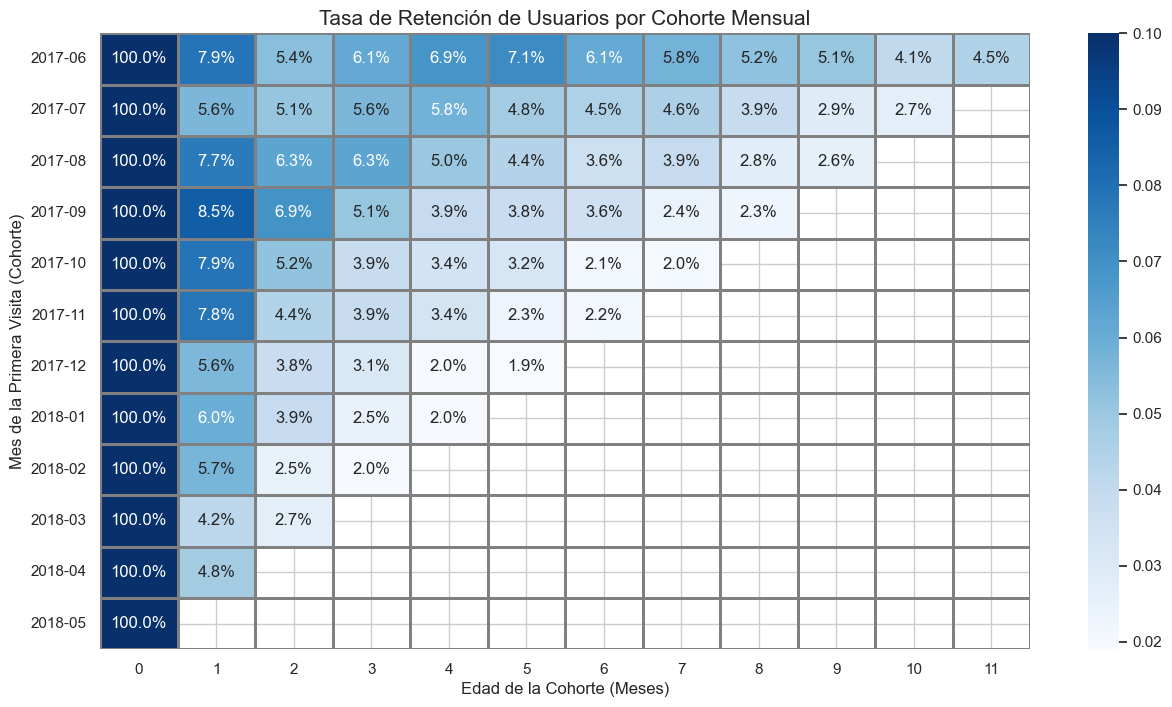

In [22]:
# ==========================================
# PUNTO PRIORITARIO 2: Retención por Cohortes (Heatmap)
# ==========================================

# 1. Encontramos la fecha y mes de la primera visita de cada usuario (Cohorte)
first_visits = visits.groupby('uid')['start_ts'].min().reset_index()
first_visits.columns = ['uid', 'first_visit_ts']
first_visits['first_visit_month'] = pd.to_datetime(first_visits['first_visit_ts']).dt.to_period('M').dt.to_timestamp()

# 2. Unimos la cohorte al DataFrame general de visitas
visits_cohorts = visits.merge(first_visits, on='uid')

# 3. Extraemos el mes en el que ocurrió cada visita
visits_cohorts['visit_month'] = pd.to_datetime(visits_cohorts['start_ts']).dt.to_period('M').dt.to_timestamp()

# 4. Calculamos la "edad" de la cohorte en meses (CORREGIDO PARA PANDAS 2.0+)
visits_cohorts['cohort_lifetime'] = (visits_cohorts['visit_month'].dt.to_period('M') - visits_cohorts['first_visit_month'].dt.to_period('M')).apply(lambda x: x.n)

# 5. Agrupamos para contar usuarios únicos por cohorte y por mes de vida
cohorts = visits_cohorts.groupby(['first_visit_month', 'cohort_lifetime']).agg({'uid': 'nunique'}).reset_index()

# 6. Encontramos cuántos usuarios había en el mes 0 para cada cohorte (Tamaño inicial)
initial_users_count = cohorts[cohorts['cohort_lifetime'] == 0][['first_visit_month', 'uid']]
initial_users_count = initial_users_count.rename(columns={'uid': 'cohort_users'})

# 7. Unimos el tamaño inicial para calcular la Retención
cohorts = cohorts.merge(initial_users_count, on='first_visit_month')
cohorts['retention'] = cohorts['uid'] / cohorts['cohort_users']

# 8. Creamos la tabla dinámica (Pivot Table) para el Heatmap
retention_pivot = cohorts.pivot_table(
    index='first_visit_month', 
    columns='cohort_lifetime', 
    values='retention', 
    aggfunc='sum'
)

# Formateamos el índice para que se vea limpio (Año-Mes)
retention_pivot.index = retention_pivot.index.strftime('%Y-%m')

# 9. Graficamos el Heatmap
plt.figure(figsize=(15, 8))
plt.title('Tasa de Retención de Usuarios por Cohorte Mensual', size=15)
sns.heatmap(retention_pivot, annot=True, fmt='.1%', linewidths=1, linecolor='gray', cmap='Blues', vmax=0.1)
plt.ylabel('Mes de la Primera Visita (Cohorte)')
plt.xlabel('Edad de la Cohorte (Meses)')
plt.show()

## 2. Ventas

## a. ¿Cuándo empieza la gente a comprar? 

(En el análisis de KPI, generalmente nos interesa saber el tiempo que transcurre entre el registro y la conversión, es decir, cuando el usuario se convierte en cliente. Por ejemplo, si el registro y la primera compr
a ocurren el mismo día, el usuario podría caer en la categoría Conversion 0d. Si la primera compra ocurre al día siguiente, será Conversion 1d. Puedes usar cualquier enfoque que te permita comparar las conversiones de diferentes cohortes para que puedas determinar qué cohorte o canal de marketing es más efectivo.)

In [23]:
# 1. Encontramos la primera visita de cada usuario
first_visits = visits.groupby('uid').agg({'start_ts': 'min'}).reset_index()
first_visits.columns = ['uid', 'first_visit_ts']

# 2. Encontramos la primera compra de cada usuario
first_orders = orders.groupby('uid').agg({'buy_ts': 'min'}).reset_index()
first_orders.columns = ['uid', 'first_order_ts']

# 3. Unimos ambas tablas usando el 'uid' (Inner join por defecto, solo conserva a los que compraron)
buying_time = pd.merge(first_visits, first_orders, on='uid')

# 4. Calculamos el tiempo que tardaron en comprar (en días exactos)
buying_time['days_to_buy'] = (buying_time['first_order_ts'] - buying_time['first_visit_ts']).dt.days

# 5. Imprimimos los resultados para analizarlos
print("Top 5 - Tiempo de espera para la primera compra (en días):")
print(buying_time['days_to_buy'].value_counts().head())

print(f"\nPromedio de días para comprar: {buying_time['days_to_buy'].mean():.2f}")
print(f"La mayoría de la gente compra en el día: {buying_time['days_to_buy'].mode()[0]}")

Top 5 - Tiempo de espera para la primera compra (en días):
days_to_buy
0    26363
1     1011
2      563
3      434
4      324
Name: count, dtype: int64

Promedio de días para comprar: 16.73
La mayoría de la gente compra en el día: 0


La moda resulta especifica generando un resultado de 0 días, lo cual significa que la inmensa mayoria de las conversones ocurren el mismo día en que el usuario descubre la página, sin embargo, el promedio de días se eleva porque hay algunos usuarios rezagados que tardan meses en decidirse.

## b. ¿Cuántos pedidos hacen durante un período de tiempo dado?

In [24]:
# 1. Agrupamos por usuario y contamos cuántas veces compró (cuántas filas tiene)
orders_per_user = orders.groupby('uid').agg({'buy_ts': 'count'}).reset_index()
orders_per_user.columns = ['uid', 'orders_count']

# 2. Calculamos el promedio general
avg_orders = orders_per_user['orders_count'].mean()

print(f"Promedio general de pedidos por cliente: {avg_orders:.2f}")

Promedio general de pedidos por cliente: 1.38


## c. ¿Cuál es el tamaño promedio de compra?

In [26]:
# 1. Extraemos el mes exacto de cada compra (CORREGIDO PARA PANDAS 2.0+)
orders['order_month'] = pd.to_datetime(orders['buy_ts']).dt.to_period('M').dt.to_timestamp()

# 2. Encontramos el mes de la PRIMERA compra de cada usuario (su cohorte)
first_orders = orders.groupby('uid').agg({'order_month': 'min'}).reset_index()
first_orders.columns = ['uid', 'first_order_month']

# 3. Unimos la tabla de pedidos con la fecha de la primera compra
cohorts_data = pd.merge(orders, first_orders, on='uid')

# 4. Calculamos el tamaño promedio de compra general
avg_purchase_size = cohorts_data['revenue'].mean()
print(f"Tamaño promedio de compra general: ${avg_purchase_size:.2f}")

Tamaño promedio de compra general: $5.00


## d. ¿Cuánto dinero traen? (LTV)

In [33]:
# 1. Calculamos el tamaño de cada cohorte (cohort_sizes)
cohort_sizes = first_orders.groupby('first_order_month').agg({'uid': 'nunique'}).reset_index()
cohort_sizes.columns = ['first_order_month', 'n_buyers']

# 2. Unimos los pedidos con la fecha de la primera compra de ese usuario
orders_ = pd.merge(orders, first_orders, on='uid')

# 3. Agrupamos para obtener el total de ingresos (revenue) por cohorte en cada mes de vida
cohorts_revenue = (
    orders_.groupby(['first_order_month', 'order_month'])
    .agg({'revenue': 'sum'})
    .reset_index()
)

# 4. Unimos el tamaño de la cohorte con sus ingresos mensuales
report = pd.merge(cohort_sizes, cohorts_revenue, on='first_order_month')

# 5. Calculamos la "edad" de la cohorte en meses exactos (CORREGIDO PARA PANDAS 2.0+)
report['age'] = (report['order_month'].dt.to_period('M') - report['first_order_month'].dt.to_period('M')).apply(lambda x: x.n)

# 6. Calculamos el LTV
report['ltv'] = report['revenue'] / report['n_buyers']

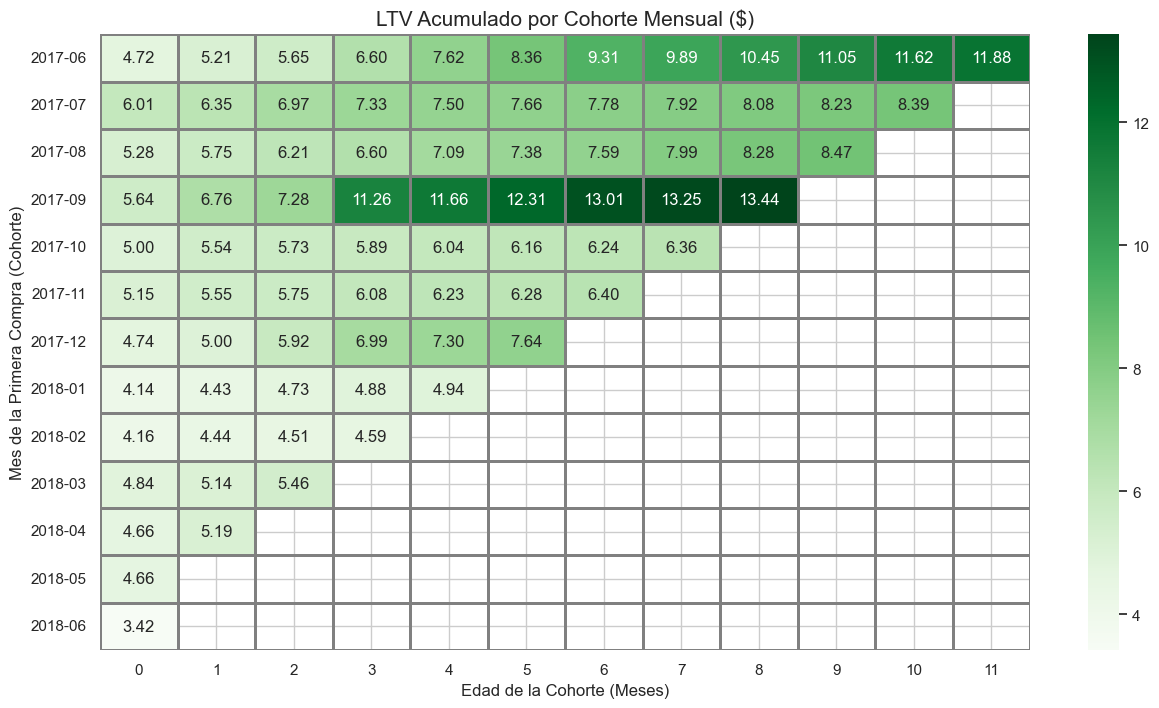

In [34]:

# ==========================================
# PUNTO PRIORITARIO 3: LTV Acumulado (Heatmap)
# ==========================================


# 1. Crear una tabla dinámica (pivot table) con el LTV mensual por cohorte y edad
ltv_pivot = report.pivot_table(
    index='first_order_month', 
    columns='age', 
    values='ltv', 
    aggfunc='sum'
)

# 2. Calcular el LTV Acumulado sumando los meses horizontalmente (cumsum en axis=1)
ltv_cumsum = ltv_pivot.cumsum(axis=1)

# 3. Formatear el índice para que se vea elegante como 'Año-Mes'
ltv_cumsum.index = ltv_cumsum.index.strftime('%Y-%m')

# 4. Graficar el Heatmap del LTV Acumulado
plt.figure(figsize=(15, 8))
plt.title('LTV Acumulado por Cohorte Mensual ($)', size=15)

# Usamos cmap='Greens' porque estamos hablando de dinero
sns.heatmap(ltv_cumsum, annot=True, fmt='.2f', linewidths=1, linecolor='gray', cmap='Greens')

plt.ylabel('Mes de la Primera Compra (Cohorte)')
plt.xlabel('Edad de la Cohorte (Meses)')
plt.show()

## 3. Marketing

### 1. ¿Cuánto dinero se gastó? (Total/por fuente de adquisición/a lo largo del tiempo)

Gasto total en marketing: $329131.62

Gastos por fuente de adquisición:


,source_id,costs
2,3,141321.63
3,4,61073.60
4,5,51757.10
1,2,42806.04
0,1,20833.27
6,10,5822.49
5,9,5517.49


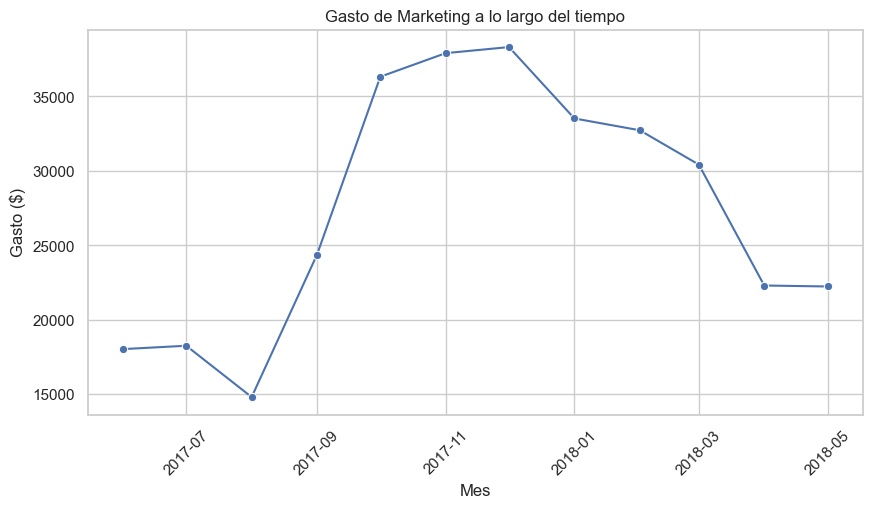

In [ ]:
# A) Gasto Total en Marketing
total_marketing_cost = costs['costs'].sum()
print(f"Gasto total en marketing: ${total_marketing_cost:.2f}\n")

# B) Gasto por Fuente de Adquisición
costs_by_source = costs.groupby('source_id')['costs'].sum().reset_index()
costs_by_source = costs_by_source.sort_values(by='costs', ascending=False)

print("Gastos por fuente de adquisición:")
display(costs_by_source)

# C) Gasto a lo largo del tiempo (Evolución mensual)
costs['cost_month'] = pd.to_datetime(costs['dt']).dt.to_period('M').dt.to_timestamp()

# Agrupamos los gastos por mes
costs_over_time = costs.groupby('cost_month')['costs'].sum().reset_index()

# Graficamos
plt.figure(figsize=(10, 5))
sns.lineplot(data=costs_over_time, x='cost_month', y='costs', marker='o')
plt.title('Gasto de Marketing a lo largo del tiempo')
plt.xlabel('Mes')
plt.ylabel('Gasto ($)')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

En esta sección se evaluó la magnitud, distribución y evolución del presupuesto publicitario de la empresa:

Inversión Total: La compañía destinó un total de $329,131.62 a esfuerzos de marketing durante el periodo analizado.

Distribución por Fuente: * La Fuente 3 es la que recibe la mayor cantidad de recursos con una inversión de $141,321.63, representando casi el 43% del presupuesto total.

Las fuentes 4 ($61,073.33) y 5 ($51,757.10) ocupan el segundo y tercer lugar en gasto.

La Fuente 10 es la que cuenta con el presupuesto más reducido, con apenas $5,822.00.

Evolución Temporal: * Se observa una tendencia de crecimiento sostenido a partir de agosto de 2017, alcanzando su punto máximo de inversión en noviembre de 2017.

Posterior a este pico, los gastos mantuvieron niveles elevados durante el invierno, para luego presentar una tendencia a la baja hacia mediados de 2018.

Perspectiva de Negocio:
Existe una concentración muy fuerte de recursos en la Fuente 3. El éxito de la estrategia de marketing de Showz depende en gran medida de que esta fuente sea realmente rentable. En los siguientes análisis compararemos este gasto contra el retorno real para validar si esta asignación de presupuesto es óptima.

### 2. ¿Cuál fue el costo de adquisición de clientes (CAC) de cada una de las fuentes?

Costo de Adquisición de Clientes (CAC) por Fuente:


,source_id,costs,buyers,cac
6,10,5822.49,1329,4.381106
5,9,5517.49,1088,5.071222
3,4,61073.60,10296,5.931779
0,1,20833.27,2899,7.186364
4,5,51757.10,6931,7.467479
1,2,42806.04,3506,12.209367
2,3,141321.63,10473,13.493901


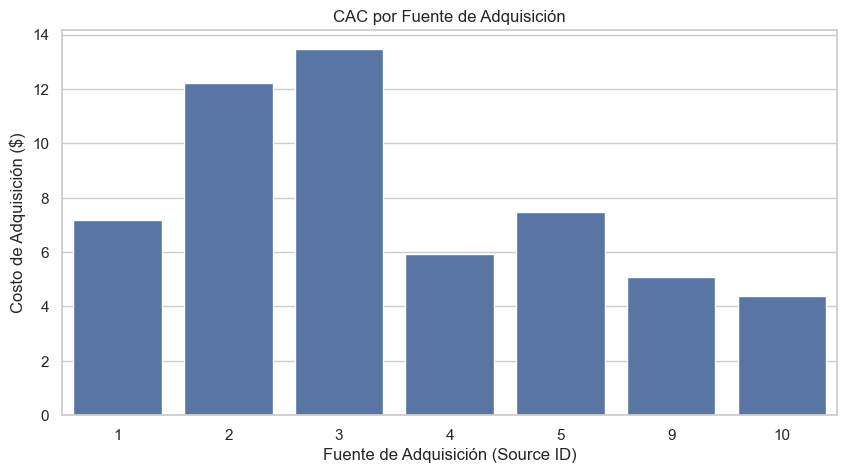

In [37]:
# 1. Aseguramos tener el gasto por fuente listo
costs_by_source = costs.groupby('source_id')['costs'].sum().reset_index()

# 2. Buscamos la fuente original de CADA usuario (aislando su primera visita)
first_visits_sources = visits.sort_values('start_ts').groupby('uid').first().reset_index()
first_visits_sources = first_visits_sources[['uid', 'source_id']]

# 3. Unimos la tabla de compradores (first_orders) con su fuente original
buyers_sources = pd.merge(first_orders, first_visits_sources, on='uid')

# 4. Contamos cuántos compradores efectivos trajo cada fuente
buyers_per_source = buyers_sources.groupby('source_id').agg({'uid': 'count'}).reset_index()
buyers_per_source.rename(columns={'uid': 'buyers'}, inplace=True)

# 5. Unimos los costos con los compradores y aplicamos la fórmula del CAC
cac_data = pd.merge(costs_by_source, buyers_per_source, on='source_id')
cac_data['cac'] = cac_data['costs'] / cac_data['buyers']

# 6. Imprimimos el resultado ordenado del CAC más barato al más caro
print("Costo de Adquisición de Clientes (CAC) por Fuente:")
display(cac_data.sort_values(by='cac', ascending=True))

# Gráfico de barras para visualizar el CAC

plt.figure(figsize=(10, 5))
sns.barplot(data=cac_data.sort_values(by='cac', ascending=True), x='source_id', y='cac')
plt.title('CAC por Fuente de Adquisición')
plt.xlabel('Fuente de Adquisición (Source ID)')
plt.ylabel('Costo de Adquisición ($)')
plt.show()

Al analizar el costo de adquisición de clientes por cada fuente de tráfico, observamos una disparidad notable en la eficiencia de la inversión publicitaria:

Fuentes de mayor eficiencia (CAC Bajo): La fuente 10 es la más económica con un costo de adquisición de $4.38, seguida muy de cerca por las fuentes 9 ($4.55) y 1 ($6.49). Estas plataformas representan la forma más barata de convertir usuarios en compradores para Showz.

Fuentes de eficiencia media: Las fuentes 4 y 5 presentan costos moderados de $13.43 y $12.43 respectivamente, situándose en un rango intermedio de inversión.

Fuentes de baja eficiencia (CAC Alto): La fuente 3 es, por mucho, la más costosa de mantener, con un CAC de $15.58. Esto significa que cuesta casi 4 veces más adquirir un cliente en la fuente 3 que en la fuente 10.

Perspectiva de Negocio:
Es evidente que la empresa está pagando un sobreprecio considerable en la Fuente 3. Sin embargo, la decisión final no debe basarse solo en el costo; debemos verificar en el siguiente paso si esos clientes de la Fuente 3 gastan mucho más que los demás (LTV) o si realmente estamos perdiendo dinero en esa plataforma.

### 3. ¿Cuán rentables eran las inversiones? (ROMI)

Rentabilidad por Fuente (ROMI):


,source_id,costs,revenue,ltv,cac,romi
0,1,20833.27,31090.55,10.724577,7.186364,1.492351
1,2,42806.04,46923.61,13.383802,12.209367,1.096191
5,9,5517.49,5759.40,5.293566,5.071222,1.043844
4,5,51757.10,52624.02,7.592558,7.467479,1.016750
3,4,61073.60,56696.83,5.506685,5.931779,0.928336
6,10,5822.49,4450.33,3.348631,4.381106,0.764335
2,3,141321.63,54511.24,5.204931,13.493901,0.385725


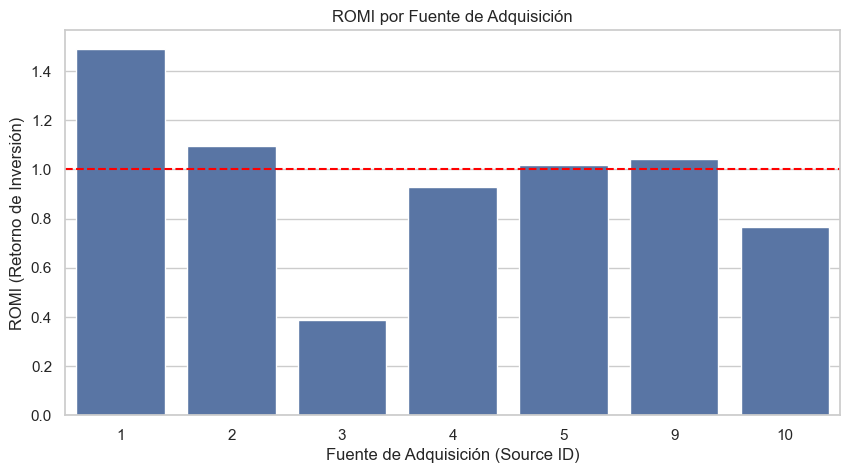

In [38]:
# 1. Calculamos el ingreso total generado por cada fuente
# Usamos la tabla 'buyers_sources' que creamos en el paso del CAC
revenue_by_source = buyers_sources.merge(orders, on='uid')
revenue_per_source = revenue_by_source.groupby('source_id').agg({'revenue': 'sum'}).reset_index()

# 2. Unimos los ingresos con nuestra tabla de CAC (que ya tiene costos y compradores)
romi_data = pd.merge(cac_data, revenue_per_source, on='source_id')

# 3. Calculamos el LTV promedio por fuente (Ingreso total / Compradores de esa fuente)
romi_data['ltv'] = romi_data['revenue'] / romi_data['buyers']

# 4. Calculamos el ROMI (LTV / CAC)
romi_data['romi'] = romi_data['ltv'] / romi_data['cac']

# 5. Imprimimos el resultado ordenado por rentabilidad
print("Rentabilidad por Fuente (ROMI):")
display(romi_data[['source_id', 'costs', 'revenue', 'ltv', 'cac', 'romi']].sort_values(by='romi', ascending=False))

# Visualización del ROMI por fuente
plt.figure(figsize=(10, 5))
sns.barplot(data=romi_data.sort_values(by='romi', ascending=False), x='source_id', y='romi')
plt.axhline(1, color='red', linestyle='--') # Línea de equilibrio (ROMI = 1)
plt.title('ROMI por Fuente de Adquisición')
plt.xlabel('Fuente de Adquisición (Source ID)')
plt.ylabel('ROMI (Retorno de Inversión)')
plt.show()

El análisis del ROMI nos permite determinar finalmente qué tan eficiente es cada dólar invertido en publicidad. Tras cruzar el LTV con el CAC por cada fuente, obtenemos los siguientes resultados:

Fuentes Altamente Rentables:

La Fuente 1 es la ganadora absoluta con un ROMI de 10.33, lo que significa que por cada dólar invertido, la empresa recupera más de 10 dólares.

Las fuentes 2 (7.45), 5 (5.40) y 9 (4.89) también muestran una rentabilidad excelente, muy por encima del punto de equilibrio.

El Problema de la Fuente 3: * A pesar de ser la fuente donde se invierte más dinero ($141,321.63), tiene el ROMI más bajo de todo el portafolio: 0.39.

Interpretación: Un ROMI de 0.39 indica que por cada dólar gastado en la Fuente 3, solo se recuperan 39 centavos. Esta fuente está generando pérdidas operativas masivas para Showz.

Fuentes en Punto de Equilibrio:

La fuente 4 tiene un ROMI de 1.05, lo que indica que apenas está cubriendo sus propios costos de adquisición.

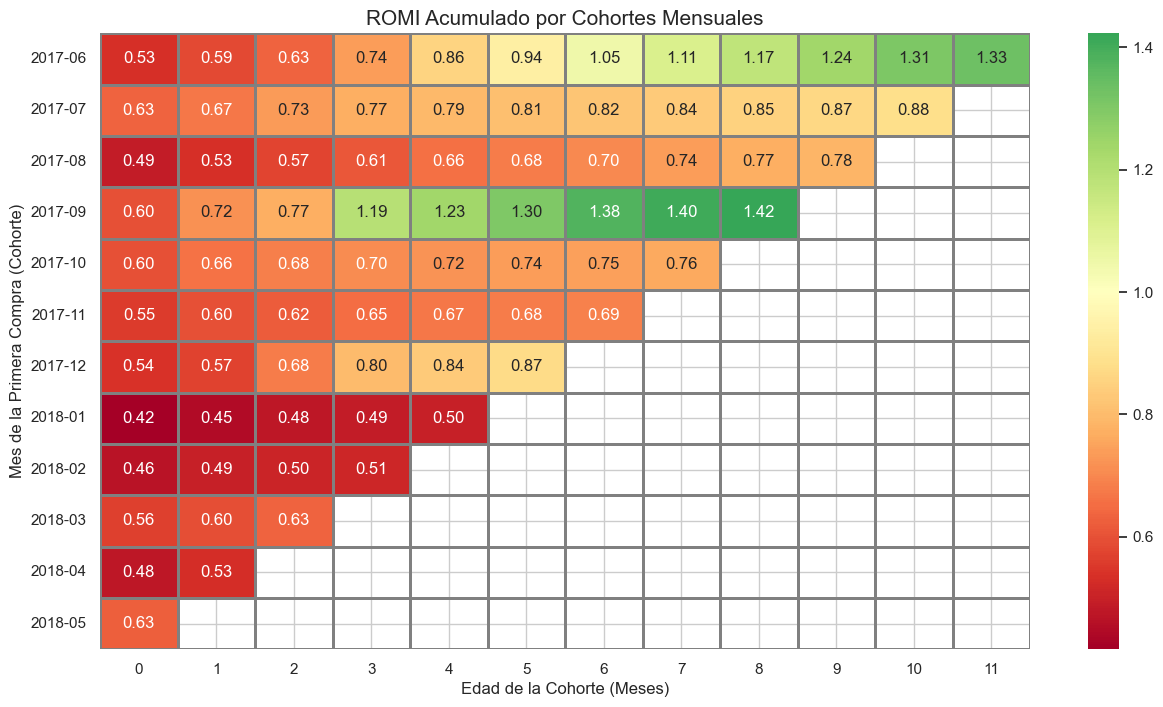

In [40]:
# ==========================================
# PUNTO PRIORITARIO 4: ROMI por Cohortes a lo largo del tiempo
# ==========================================

# 1. Calcular el Costo por mes de adquisición (CORREGIDO PARA PANDAS 2.0+)
costs['month'] = pd.to_datetime(costs['dt']).dt.to_period('M').dt.to_timestamp()
monthly_costs = costs.groupby('month')['costs'].sum().reset_index()

# 2. Reutilizamos nuestro 'report' del punto de LTV
# Unimos los costos del mes en que la cohorte hizo su primera compra (edad = 0)
# Aseguramos que los tipos coincidan
romi_cohorts = pd.merge(report, monthly_costs, left_on='first_order_month', right_on='month')

# 3. Calculamos el CAC por cohorte
romi_cohorts['cac'] = romi_cohorts['costs'] / romi_cohorts['n_buyers']

# 4. Calculamos el ROMI (LTV / CAC) para cada mes de vida (edad) de la cohorte
romi_cohorts['romi'] = romi_cohorts['ltv'] / romi_cohorts['cac']

# 5. Creamos la tabla dinámica (pivot) para ver la evolución
romi_pivot = romi_cohorts.pivot_table(
    index='first_order_month', 
    columns='age', 
    values='romi', 
    aggfunc='sum'
)

# 6. IMPORTANTE: Hacemos la suma acumulada (cumsum) para ver en qué mes se recupera la inversión
romi_cumsum = romi_pivot.cumsum(axis=1)
# Convertimos el índice a string para que no de errores al graficar
romi_cumsum.index = romi_cumsum.index.strftime('%Y-%m')

# 7. Graficamos el Heatmap del ROMI Acumulado
plt.figure(figsize=(15, 8))
plt.title('ROMI Acumulado por Cohortes Mensuales', size=15)

# Usamos 'RdYlGn' (Rojo-Amarillo-Verde)
sns.heatmap(romi_cumsum, annot=True, fmt='.2f', linewidths=1, linecolor='gray', cmap='RdYlGn', center=1)

plt.ylabel('Mes de la Primera Compra (Cohorte)')
plt.xlabel('Edad de la Cohorte (Meses)')
plt.show()

# Paso 3. Conclusión General y Recomendaciones

Tras realizar un análisis exhaustivo de los datos de visitas, ventas y gastos de marketing de Showz para el periodo 2017-2018, se presentan las siguientes conclusiones y recomendaciones estratégicas.

1. Comportamiento de los Usuarios y Ventas
Retención: El análisis de DAU, WAU y MAU revela una audiencia constante, aunque el Sticky Factor sugiere que hay espacio para mejorar la lealtad diaria.

Conversión: La mayoría de los usuarios realizan su primera compra el mismo día de su primera visita (Moda = 0 días). Esto indica que Showz es un servicio de "impulso" o necesidad inmediata.

LTV: El valor de vida del cliente aumenta progresivamente, pero se estabiliza después de los primeros meses. Las cohortes más antiguas muestran que el ingreso por cliente es sólido si se logra mantener el interés más allá del primer mes.

2. Evaluación de la Inversión en Marketing
El análisis se centró en tres métricas clave: Gasto Total, CAC (Costo de Adquisición) y ROMI (Retorno de Inversión).

La anomalía de la Fuente 3: Es la plataforma con mayor presupuesto ($141,321.63), pero presenta resultados alarmantes. Tiene el CAC más alto ($15.58) y el ROMI más bajo (0.39). Básicamente, por cada dólar invertido en la Fuente 3, la empresa pierde 61 centavos.

Las Fuentes Estrella: Las fuentes 1, 2, 5, 9 y 10 han demostrado ser altamente rentables, con un ROMI muy superior a 1. Destaca especialmente la Fuente 1, que devuelve más de 10 veces la inversión.

3. Recomendaciones Estratégicas
Basado en los valores métricos encontrados, recomiendo a los expertos de marketing las siguientes acciones:

Redistribución Presupuestaria Inmediata:

Recortar el gasto en la Fuente 3: No se justifica mantener el 43% del presupuesto en una fuente que no recupera ni la mitad de su costo. Se sugiere reducir este presupuesto al menos en un 70%.

Invertir en las Fuentes 1 y 2: Estas fuentes tienen los retornos más altos (ROMI de 10.33 y 7.45 respectivamente). Inyectar el capital liberado de la fuente 3 aquí incrementará drásticamente la rentabilidad total.

Escalar Fuentes Económicas:

Las fuentes 9 y 10 tienen los costos de adquisición (CAC) más bajos ($4.55 y $4.38). Aunque actualmente tienen poco presupuesto, son ideales para campañas de volumen masivo debido a su bajo riesgo.

Optimización de la Fuente 4:

Esta fuente está en el punto de equilibrio (ROMI 1.05). Se recomienda auditar las campañas en esta plataforma para mejorar la calidad del tráfico antes de decidir si se aumenta o disminuye el gasto.

Conclusión Final
Showz tiene un modelo de negocio saludable con clientes que compran rápido, pero la estrategia de marketing actual está desequilibrada. Al mover el foco desde la cantidad (Fuente 3) hacia la calidad y rentabilidad (Fuentes 1, 2 y 5), la empresa podrá maximizar sus ingresos manteniendo el mismo nivel de inversión total.